## 🐻‍❄️ 투빅스 25&26기 5주차 2교시 — CLIP 직접 구현 & Modality Gap 관찰

#### ✅ 과제 목적
멀티모달 표현학습에서 가장 널리 쓰이는 CLIP(Radford et al., 2021)을 처음부터 직접 만들어 봅니다.
서로 다른 데이터로 각자 학습된 두 unimodal encoder를 가져와, 논문이 제안한 구조 그대로
projection, learnable temperature, symmetric InfoNCE를 구현하고 학습시킵니다.

직접 만든 CLIP이 어느 정도 정렬에 성공하고 나면, 그 정렬이 실제로 얼마나 "완전한"지 되짚어 보는
심화 선택 파트가 이어집니다. 사전학습이 훨씬 많이 된 공개 CLIP조차 이미지와 텍스트 embedding을
완전히 같은 자리에 겹쳐 놓지는 못한다는 modality gap 현상(Liang et al., 2022)을 직접 눈으로 확인합니다.

> - **Part A. CLIP 직접 구현 (필수)** — 서로 다른 두 unimodal encoder를 가져와 projection, learnable temperature,
>   symmetric InfoNCE를 직접 짜고 학습시킵니다.
> - **Part B. Modality Gap 관찰 (심화 선택)** — 사전학습 CLIP을 불러와 정렬 이후에도 남아 있는 gap을 시각화하고 측정합니다.

> 이 노트북은 아래 두 논문을 그대로 따라갑니다. CLIP Part는 논문과제 및 세션과제와 연관지어 활용하시면 됩니다.
> - CLIP: Radford et al., [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020) (2021)
> - Modality Gap: Liang et al., [Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning](https://arxiv.org/abs/2203.02053) (NeurIPS 2022)

> **데이터셋:** [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k) (Hugging Face `jxie/flickr8k`)
> - 이미지 8,000장(train 6,000 / val 1,000 / test 1,000), 이미지 하나당 caption 5개
> - Part A는 train 2,000장, test 500장을, Part B는 test에서 300장을 사용합니다.

> **Part A에서 사용하는 encoder:**
> - 이미지: `google/vit-base-patch16-224-in21k` — ImageNet-21k 이미지 분류로만 학습 (텍스트를 본 적 없음)
> - 텍스트: `distilbert-base-uncased` — 영어 텍스트 코퍼스로만 학습 (이미지를 본 적 없음)
> - 두 encoder 모두 이미지-텍스트 쌍을 함께 본 적이 없습니다. Alignment 부분은 우리가 처음부터 만들어야 합니다.
> - 두 encoder는 backbone을 froze 하고 feature만 뽑아 씁니다. 우리가 학습하는 부분은 그 위에 올라가는 얇은 층뿐입니다.

> **Part B에서 사용하는 모델:** `openai/clip-vit-base-patch32` — 이미지-텍스트 쌍으로 이미 학습이 끝난 공개 체크포인트

#### ✅ 주의 사항
> - 코드 셀의 `# ===== TODO n =====` 블록을 순서대로 채우세요.
> - ⚠️ Hugging Face에서 데이터셋을 내려받으므로 토큰 로그인이 되어 있어야 합니다.
> - `MY_SEED`(본인 학번 뒷 4자리)를 꼭 채우세요.
> - 자체 GPU 혹은 Colab GPU 런타임을 활용하세요.
> - Part A의 서술형 문제는 총 2문항, Part B(심화 선택)는 1문항입니다. 모두 본인이 직접 실행한 결과를 활용해 답변하시면 됩니다.

#### ✅ 제출물
> - Part A: 빈칸을 모두 채우고 전부 실행한 이 노트북 (출력 포함) — 필수
> - Part B: 선택과제
> - 기술블로그 '과제 복습' 섹션 — 이번 실습에서 CLIP 논문의 어느 부분을 구현했는지 정리

### 🗺️ 실습 흐름

> **Part A. CLIP 직접 구현 (필수)**
0. 환경 설정
1. 데이터 준비
2. 두 개의 unimodal encoder에서 feature 추출
3. Heterogeneity Gap 확인 — 정렬 전 두 공간은 왜 그냥 비교할 수 없는가
4. 준비 — 작은 예시로 정렬의 핵심 아이디어 먼저 만져보기
5. Projection — 두 공간을 잇는 다리
6. Learnable Temperature — 유사도를 얼마나 뾰족하게 볼 것인가
7. 손실함수, 절반만 — 한쪽 방향만 맞추면 생기는 일
8. Symmetric InfoNCE — CLIP의 완성된 손실함수
9. 학습 전후 retrieval 비교
10. 학습된 모델이 어떻게 맞히고 틀리는지 보기

> **Part B. Modality Gap 관찰 (심화 선택)**
11. 사전학습 CLIP 불러오기 & embedding 뽑기
12. 두 modality가 실제로 겹쳐 있는지 시각화
13. Gap은 학습 때문에 생기는가, 초기화 때문에 생기는가
14. Gap을 숫자로 재보기

### 📖 논문 대응표

| 노트북 | 논문 근거 |
|---|---|
| 3장 Heterogeneity Gap | CLIP 논문 Section 1 — 서로 다르게 사전학습된 encoder는 같은 벡터 공간을 공유하지 않는다는 문제의식 |
| 5장 Projection | CLIP 논문 Section 2.3, Figure 3의 `W_i`, `W_t`. "우리는 linear projection만 사용했다"는 저자들의 명시적 선택 |
| 6장 Learnable Temperature | CLIP 논문 Section 2.5 — temperature를 0.07에서 시작해 학습, logit이 100을 넘지 않도록 clip |
| 7~8장 손실함수 | CLIP 논문 Figure 3 pseudocode — `loss_i`, `loss_t`를 각각 구해 평균 |
| 9~10장 Retrieval 평가 | CLIP 논문 Section 3.2 — 학습된 embedding으로 image-text retrieval 성능 측정 |
| 12장 PCA 시각화 | Modality Gap 논문 Section 3, Figure 1 — 정렬 이후에도 이미지·텍스트 embedding이 분리된 두 덩어리를 이룬다는 관찰 |
| 13장 랜덤 초기화 비교 | Modality Gap 논문 Section 4.1 "The Cone Effect" — 학습 전 랜덤 초기화 상태에서도 gap이 존재한다는 분석 |
| 14장 Gap 크기 측정 | Modality Gap 논문 Section 3 — 두 modality 중심 사이의 유클리드 거리(Δ)로 gap을 정량화 |

# 🧭 Part A. CLIP 직접 구현 (필수)

In [ ]:
# 라이브러리 설치
!pip -q install "transformers>=4.40,<5" "datasets>=2.19" scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 16.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


### ⚙️ 0. 환경 설정 — 라이브러리, 학생별 시드, 파생 변수

In [ ]:
import math
import random
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer

# ---- 실습 설정 ----
N_TRAIN_IMAGES = 2000      # CLIP 학습용
N_TEST_IMAGES = 500        # 평가용. retrieval 후보 개수가 곧 이 값
IMG_BACKBONE = "google/vit-base-patch16-224-in21k"   # 이미지만 본 encoder
TXT_BACKBONE = "distilbert-base-uncased"             # 텍스트만 본 encoder
PROJ_DIM = 256             # 공동 embedding 공간의 차원
EPOCHS = 30                # CLIP 학습 epoch
BATCH_SIZE = 256
LR = 1e-3

# ===== TODO 0 =====
# 본인 학번 뒷 4자리를 넣으세요. (예: 202612345 -> 2345)
MY_SEED = 8734               # TODO: 학번 뒷 4자리
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
# ==================

TRAIN_POOL = 6000
TEST_POOL = 1000
TRAIN_OFFSET = MY_SEED % (TRAIN_POOL - N_TRAIN_IMAGES)
TEST_OFFSET = MY_SEED % (TEST_POOL - N_TEST_IMAGES)
SHOW_IDX = MY_SEED % N_TEST_IMAGES

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device      :", device)
print("MY_SEED     :", MY_SEED)
print("train 구간  : train[%d:%d]" % (TRAIN_OFFSET, TRAIN_OFFSET + N_TRAIN_IMAGES))
print("test  구간  : test[%d:%d]" % (TEST_OFFSET, TEST_OFFSET + N_TEST_IMAGES))
print("확인할 샘플 : test image", SHOW_IDX)
if device == "cpu":
    print("\n⚠️ GPU가 아닙니다. 런타임 > 런타임 유형 변경에서 GPU를 켜세요.")


device      : cuda
MY_SEED     : 8734
train 구간  : train[734:2734]
test  구간  : test[234:734]
확인할 샘플 : test image 234


### 📦 1. 데이터 준비
> Flickr8k를 사용합니다. 이미지 하나당 사람이 직접 쓴 caption이 5개씩 붙어 있습니다.

In [ ]:
train_ds = load_dataset("jxie/flickr8k", split=f"train[{TRAIN_OFFSET}:{TRAIN_OFFSET + N_TRAIN_IMAGES}]")
test_ds = load_dataset("jxie/flickr8k", split=f"test[{TEST_OFFSET}:{TEST_OFFSET + N_TEST_IMAGES}]")
print("train images:", len(train_ds), "| 구간 train[%d:%d]" % (TRAIN_OFFSET, TRAIN_OFFSET + N_TRAIN_IMAGES))
print("test  images:", len(test_ds), "| 구간 test[%d:%d]" % (TEST_OFFSET, TEST_OFFSET + N_TEST_IMAGES))

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00000-of-00002-2f8f6bfa852eac(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-2173151d8cd6c7(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00001-of-00002-2173151d8cd6c7(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-42a2661d12c73e4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

train images: 2000 | 구간 train[734:2734]
test  images: 500 | 구간 test[234:734]


test image 234의 caption 5개:
  caption_0: A closeup of an older man with glasses speaking .
  caption_1: A man wearing a blue shirt and glasses .
  caption_2: A man with black-rimmed glasses and a mustache is talking .
  caption_3: A man with glasses and a mustache is in the middle of a sentence .
  caption_4: An older man with glasses is looking off camera .


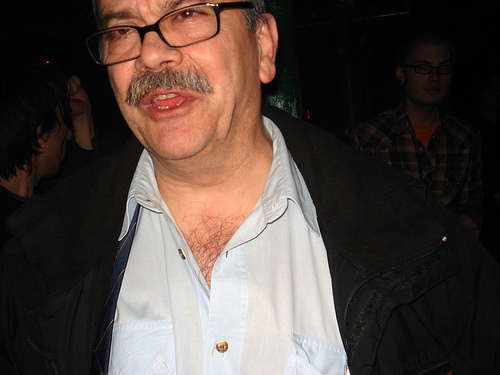

In [ ]:
def get_all_captions(ds):
    # 이미지 하나당 caption 5개를 [[c0..c4], [c0..c4], ...] 형태로 모읍니다.
    cols = [ds[f"caption_{k}"] for k in range(5)]
    return [list(t) for t in zip(*cols)]


train_caps = get_all_captions(train_ds)
test_caps = get_all_captions(test_ds)

print(f"test image {SHOW_IDX}의 caption 5개:")
for k, c in enumerate(test_caps[SHOW_IDX]):
    print(f"  caption_{k}: {c.strip()}")

test_ds[SHOW_IDX]["image"]

#### 👀 1-1. 데이터 확인해보기

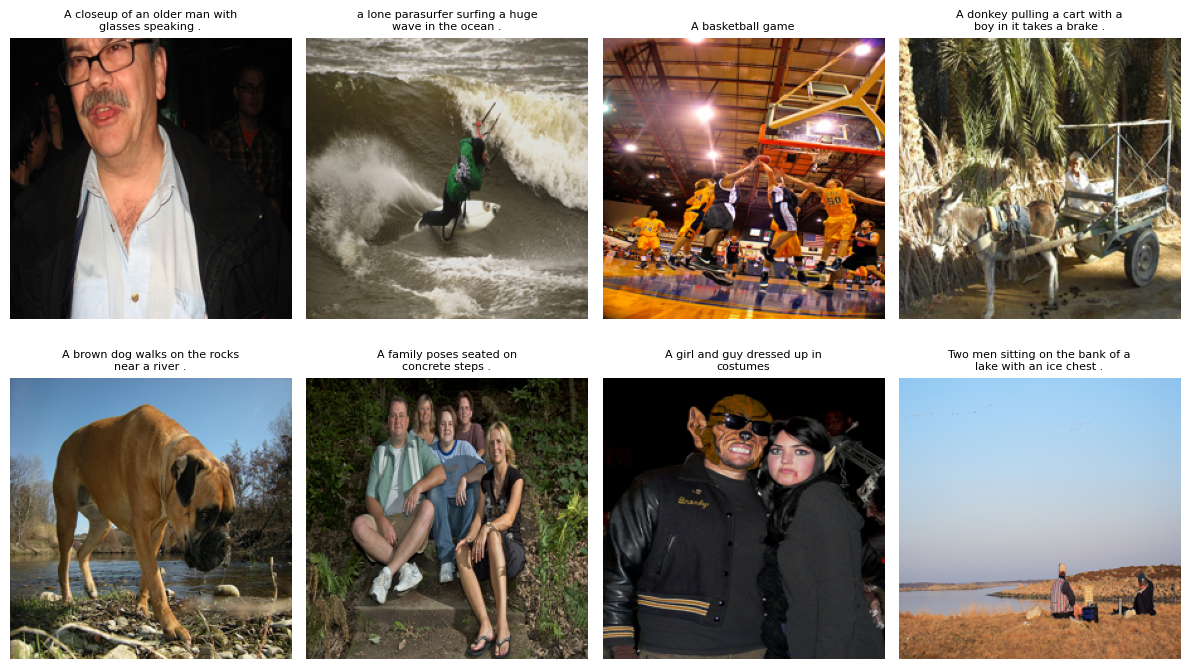

In [ ]:
import textwrap


def img_of(ds, i, size=(224, 224)):
    return ds[i]["image"].convert("RGB").resize(size)


def show_image_grid(images, titles, ncols=4, width=3.0, height=3.6, fontsize=8, wrap=32):
    """이미지 여러 장을 캡션과 함께 격자로 출력합니다."""
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, height * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title("\n".join(textwrap.wrap(title, wrap)), fontsize=fontsize)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


sample_idx = [(SHOW_IDX + k) % N_TEST_IMAGES for k in range(8)]
show_image_grid(
    [img_of(test_ds, i) for i in sample_idx],
    [test_caps[i][0].strip() for i in sample_idx],
)

### 🧠 2. 두 개의 unimodal encoder에서 feature 뽑기

> 📖 **논문 근거** — CLIP 논문은 image encoder와 text encoder를 각각 독립적으로 두고, 둘 다 처음부터 함께 학습시킵니다.
> 우리는 학습 시간을 줄이기 위해 이미 학습이 끝난 두 encoder를 "이미지만 본 것"과 "텍스트만 본 것"으로 하나씩 가져와,
> 그 위에만 CLIP의 나머지 부분(projection, temperature, loss)을 구현합니다.
> 원 논문처럼 두 encoder를 처음부터 함께 학습시키는 대신, 이미 존재하는 unimodal encoder로 실험 규모를 줄인 구성입니다.

| | 모델 | 무엇으로 학습됐나 | 출력 차원 |
|---|---|---|---|
| 이미지 | `google/vit-base-patch16-224-in21k` | ImageNet-21k 이미지 분류 (텍스트 안 봄) | 768 |
| 텍스트 | `distilbert-base-uncased` | 영어 코퍼스 MLM (이미지 안 봄) | 768 |

두 encoder는 backbone을 frozen 상태로 두고 feature만 뽑습니다.
한 번 뽑아 두면 뒤에 나오는 학습·평가를 몇 초 만에 반복할 수 있고,
우리가 비교하려는 부분(projection, 손실함수) 말고 다른 변수가 활용되지 않습니다.

#### ✏️ ===== TODO 1 =====

> 📖 **논문 근거** — Figure 3 pseudocode의 `l2_normalize`

cosine similarity는 두 벡터가 같은 방향을 보는지만 재고 길이는 보지 않습니다.

그래서 비교하기 전에 길이를 1로 맞춰 둬야 합니다. `l2norm`을 완성하세요.

In [ ]:
img_proc = AutoImageProcessor.from_pretrained(IMG_BACKBONE, use_fast=True)
img_backbone = AutoModel.from_pretrained(IMG_BACKBONE).to(device).eval()
tokenizer = AutoTokenizer.from_pretrained(TXT_BACKBONE)
txt_backbone = AutoModel.from_pretrained(TXT_BACKBONE).to(device).eval()

for p in img_backbone.parameters():
    p.requires_grad = False
for p in txt_backbone.parameters():
    p.requires_grad = False

D_IMG = img_backbone.config.hidden_size
D_TXT = txt_backbone.config.hidden_size
MAX_LEN = 24          # 텍스트 토큰 길이

print("image backbone dim:", D_IMG, "| text backbone dim:", D_TXT)
print("두 backbone의 출력 차원이 %s" % ("같습니다. 같은 공간인지는 3장에서 확인합니다."
                                      if D_IMG == D_TXT else "다릅니다."))


def l2norm(x):
    # ===== TODO 1 =====
    # 힌트: 각 벡터를 자기 길이로 나누면 길이가 1이 됩니다. 마지막 축(dim=-1) 기준입니다.
    return x / x.norm(dim=-1, keepdim=True)  # TODO: 여기에 코드를 작성하세요
    # ==================

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


image backbone dim: 768 | text backbone dim: 768
두 backbone의 출력 차원이 같습니다. 같은 공간인지는 3장에서 확인합니다.


In [ ]:
@torch.no_grad()
def encode_images(ds, batch_size=64):
    """frozen ViT로 이미지 feature를 뽑습니다. CLS token을 pooled feature로 씁니다."""
    pooled = []
    for start in range(0, len(ds), batch_size):
        images = [im.convert("RGB") for im in ds[start:start + batch_size]["image"]]
        inputs = img_proc(images=images, return_tensors="pt").to(device)
        out = img_backbone(**inputs).last_hidden_state
        pooled.append(out[:, 0].cpu())   # CLS token
    return torch.cat(pooled)


@torch.no_grad()
def encode_texts(texts, batch_size=128):
    """frozen DistilBERT로 텍스트 feature를 뽑습니다. 패딩을 뺀 토큰 평균을 pooled feature로 씁니다."""
    pooled = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        inputs = tokenizer(batch, padding="max_length", truncation=True,
                            max_length=MAX_LEN, return_tensors="pt").to(device)
        out = txt_backbone(**inputs).last_hidden_state
        mask = inputs["attention_mask"].unsqueeze(-1).float()
        mean = (out * mask).sum(1) / mask.sum(1)
        pooled.append(mean.cpu())
    return torch.cat(pooled)

In [ ]:
# ---- feature 추출 ----
t_start = time.time()

train_img = encode_images(train_ds)
test_img = encode_images(test_ds)

# 학습에는 caption 5개를 모두 사용합니다.
train_txt = encode_texts([c[k] for c in train_caps for k in range(5)]).view(N_TRAIN_IMAGES, 5, D_TXT)
test_txt = encode_texts([c[0] for c in test_caps])

print("이미지 feature :", tuple(train_img.shape), tuple(test_img.shape))
print("텍스트 feature :", tuple(train_txt.shape), tuple(test_txt.shape))
print("소요 시간: %.1f초" % (time.time() - t_start))

이미지 feature : (2000, 768) (500, 768)
텍스트 feature : (2000, 5, 768) (500, 768)
소요 시간: 60.8초


### 🕳️ 3. Heterogeneity Gap — 정렬되지 않은 두 공간

두 backbone의 출력은 똑같이 768차원입니다. 차원이 같으니 그냥 내적해도 되지 않을까요?

CLIP을 만들기 시작하기 전에, 이 생각이 맞는지부터 확인해 보겠습니다.

> 세션에서 언급한 것 처럼 서로 다른 학습 목표로 만들어진 두 벡터 공간은 차원이 같아도 그 축이 의미하는 바가 다릅니다.
> 이 문제는 cross-modal retrieval 연구에서 흔히 heterogeneity gap이라 부릅니다 — 서로 다른 modality의
> 표현이 통계적으로 이질적이어서, 형식(shape)이 같아도 곧바로 비교할 수 없다는 것입니다.

#### ✏️ ===== TODO 2 =====
정규화한 raw feature로, 아무 학습 없이 similarity 행렬을 만드세요.

`similarity[i][j]`는 i번째 이미지와 j번째 캡션의 cosine similarity이고 정답 pair는 대각선 (i, i)입니다.

In [ ]:
def retrieval_scores(sim):
    """sim[i][j]는 image i와 caption j의 유사도이고, 정답은 대각선에 있습니다.

    rank는 정답보다 점수가 높은 후보의 수에 1을 더한 값입니다. 정답이 1등이면 1이 됩니다.
    """
    n = sim.size(0)
    out = {}
    for name, s in [("i2t", sim), ("t2i", sim.T)]:
        rank = (s > s.diag().unsqueeze(1)).sum(dim=1) + 1
        for k in (1, 5, 10):
            out["%s R@%d" % (name, k)] = (rank <= k).float().mean().item()
        out["%s medr" % name] = rank.float().median().item()
    return out


# ===== TODO 2 =====
# 힌트: 두 feature를 각각 l2norm 한 뒤 (N, D) @ (D, N) -> (N, N)
sim_raw = l2norm(test_img) @ l2norm(test_txt).T  # TODO: 여기에 코드를 작성하세요
# ==================

raw = retrieval_scores(sim_raw)
chance = 1.0 / N_TEST_IMAGES

from IPython.display import display


def format_compare(df):
    """R@k는 %로, medr은 소수 첫째 자리로 바꿔 보기 좋게 표시합니다. (노트북 전체에서 재사용)"""
    styled = df.copy()
    for col in styled.columns:
        if "R@" in col:
            styled[col] = (styled[col] * 100).map(lambda x: "%.1f%%" % x)
        else:
            styled[col] = styled[col].map(lambda x: "%.1f" % x)
    return styled


print("[정렬 전] frozen feature를 그대로 내적한 결과")
display(format_compare(pd.DataFrame([raw], index=["정렬 전 (frozen feature)"])))
print("chance 수준 R@1         : %.4f" % chance)
print("chance 수준 median rank : %.1f" % (N_TEST_IMAGES / 2))
print("대각선(정답) 평균 유사도  : %.4f" % sim_raw.diag().mean())
off = sim_raw.clone().fill_diagonal_(float("nan"))
print("비대각선(오답) 평균 유사도: %.4f" % np.nanmean(off.numpy()))


[정렬 전] frozen feature를 그대로 내적한 결과


,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.2%,1.2%,2.0%,252.0,0.0%,1.0%,2.0%,248.0


chance 수준 R@1         : 0.0020
chance 수준 median rank : 250.0
대각선(정답) 평균 유사도  : 0.0136
비대각선(오답) 평균 유사도: 0.0134


#### 📝 서술형 문제 1

위 출력의 숫자를 인용해서 답하세요.

1. 두 backbone의 출력은 똑같이 768차원인데도 retrieval 성능이 chance 수준입니다.
   `i2t R@1`과 `median rank`를 chance 값과 비교해 인용하고, 이것이 heterogeneity gap과 어떻게 연결되는지 설명하세요. i2t R@1은 0.2%로 chance 수준인 0.2%와 같고 median rank도 252로 chance 값 250과 거의 같다 같은 768차원이라도 두 backbone의 공간이 서로 달라 바로 비교할 수 없으며 이것이 heterogeneity gap이다
2. 대각선(정답 pair) 평균과 비대각선(오답 pair) 평균을 인용하세요. 두 값의 차이가 거의 없다는 사실은
   "정렬"이 어떤 종류의 작업인지에 대해 무엇을 말해 주나요? pair 평균은 0.0136이고 오답 pair 평균은 0.0134로 거의 차이가 없다 따라서 정렬은 차원만 맞추는 것이 아니라 정답 pair는 가깝게 하고 오답 pair는 멀어지게 만드는 작업이다


### 🧪 4. 준비 — 작은 예시로 감 잡기

실제 데이터로 넘어가기 전에, 지금부터 만들 세 가지 요소(정렬된 벡터, temperature, InfoNCE)를
숫자가 눈에 보이는 작은 예시에 먼저 적용해 봅니다. 이미지 4개와 캡션 4개가 있고,
이미 어떤 방법으로든 정렬이 끝났다고 가정한 4차원 벡터를 준비했습니다.

이 4×4 유사도 행렬에서 대각선(정답)이 비대각선(오답)보다 얼마나 높은지, temperature를 곱하면 그 차이가
어떻게 벌어지는지, 그 결과에 cross entropy를 적용하면 loss가 왜 작아지는지를 눈으로 먼저 확인합니다.
실제 768차원 데이터에서도 이 과정이 그대로 벌어지지만, 숫자가 너무 많아 눈으로 보기 어려울 뿐입니다.

#### ✏️ ===== TODO 3 =====
`toy_img`, `toy_txt`를 각각 l2norm 한 뒤 내적해서 4×4 유사도 행렬 `toy_sim`을 만드세요. (TODO 2와 같은 방식입니다.)

In [ ]:
toy_img = torch.tensor([
    [0.90, 0.10, 0.05, 0.05],
    [0.10, 0.90, 0.05, 0.05],
    [0.05, 0.05, 0.90, 0.10],
    [0.05, 0.05, 0.10, 0.90],
])
torch.manual_seed(MY_SEED)
toy_txt = toy_img + 0.05 * torch.randn(4, 4)   # 캡션은 이미지와 비슷하지만 완전히 같지는 않음

# ===== TODO 3 =====
# 힌트: TODO 2와 똑같은 방식입니다. 두 feature를 각각 l2norm 한 뒤 내적하세요.
toy_sim = l2norm(toy_img) @ l2norm(toy_txt).T  # TODO: 여기에 코드를 작성하세요
# ==================

toy_sim_df = pd.DataFrame(
    toy_sim.numpy(),
    index=["image %d" % i for i in range(4)],
    columns=["caption %d" % j for j in range(4)],
)
print("4x4 유사도 행렬 (행: 이미지, 열: 캡션)")
display(toy_sim_df.round(3))
print()
print("대각선(정답) 평균 : %.3f" % toy_sim.diag().mean())
toy_off = toy_sim.clone().fill_diagonal_(float("nan"))
print("비대각선(오답) 평균: %.3f" % np.nanmean(toy_off.numpy()))


4x4 유사도 행렬 (행: 이미지, 열: 캡션)


,caption 0,caption 1,caption 2,caption 3
image 0,0.993,0.242,0.078,0.123
image 1,0.180,1.000,0.154,0.249
image 2,0.054,0.101,0.997,0.294
image 3,0.185,0.127,0.182,0.989



대각선(정답) 평균 : 0.995
비대각선(오답) 평균: 0.164


대각선이 비대각선보다 확실히 높게 나왔을 겁니다. 이제 이 차이를 온도(temperature)로 조절해 보겠습니다.

cosine similarity는 항상 [-1, 1] 사이에 있어서, 그대로 softmax에 넣으면 1등과 나머지 등수의 확률 차이가 크게 벌어지지 않습니다.
즉 1등이 0.38의 값이어도 2등이 0.36으로 차이가 크게 벌어지지 않을 수 있습니다.
그래서 유사도에 어떤 수를 곱해 분포를 뾰족하게 만듭니다. 이 수가 `exp(t)`이고, 그 역수가 temperature입니다.
temperature가 작을수록(곱하는 수가 클수록) 정답의 확률이 커집니다.

#### ✏️ ===== TODO 4 =====
`toy_sim`의 첫 번째 행(이미지 0)에 온도를 다르게 곱해 softmax를 통과시키고, 정답(캡션 0)에 할당된 확률을 비교하세요.

In [ ]:
rows = []
for temp in [1.0, 0.07, 0.01]:
    # ===== TODO 4 =====
    # 힌트: logits = (1/temperature) * 유사도. F.softmax(logits, dim=-1)로 확률을 만드세요.
    probs = F.softmax(toy_sim[0] / temp, dim=-1)   # TODO: 여기에 코드를 작성하세요
    # ==================
    row = {"temperature": temp, "정답(캡션 0) 확률": probs[0].item()}
    row.update({"caption %d 확률" % j: probs[j].item() for j in range(4)})
    rows.append(row)

display(pd.DataFrame(rows).set_index("temperature").round(4))


,정답(캡션 0) 확률,caption 0 확률,caption 1 확률,caption 2 확률,caption 3 확률
temperature,,,,,
1.00,0.4366,0.4366,0.2059,0.1747,0.1828
0.07,1.0000,1.0000,0.0000,0.0000,0.0000
0.01,1.0000,1.0000,0.0000,0.0000,0.0000


확률이 뾰족해질수록 정답에 걸리는 확률이 올라가는 게 보입니다. 이제 이 확률로 loss를 계산해 보겠습니다.

CLIP은 이 문제를 "i번째 이미지의 정답 캡션을 N개(여기서는 4개) 중에서 고르는 분류 문제"로 봅니다.
정답 label이 `[0, 1, 2, 3]`이 되므로 cross entropy를 그대로 쓸 수 있습니다.

#### ✏️ ===== TODO 5 =====
`toy_sim` 전체에 temperature 0.07을 적용해 cross entropy loss를 구하세요. `torch.arange`로 정답 label을 만드는 것이 힌트입니다.

In [ ]:
temp = 0.07
# ===== TODO 5 =====
# 힌트 1: logits = toy_sim / temp
# 힌트 2: 정답 label은 [0, 1, 2, 3] -> torch.arange(4)
toy_logits = toy_sim / temp   # TODO: 여기에 코드를 작성하세요
toy_labels = torch.arange(4) # TODO: 여기에 코드를 작성하세요
toy_loss = F.cross_entropy(toy_logits, toy_labels)     # TODO: 여기에 코드를 작성하세요
# ==================

print("toy InfoNCE loss (image -> text 방향): %.4f" % toy_loss.item())
print("완전히 무작위였다면 나왔을 loss (log 4) : %.4f" % math.log(4))
print("이미 정렬된 예시라 loss가 훨씬 작게 나옵니다. 실제 CLIP 학습은 이 loss를 줄이는 방향으로 projection을 조금씩 움직이는 과정입니다.")

toy InfoNCE loss (image -> text 방향): 0.0000
완전히 무작위였다면 나왔을 loss (log 4) : 1.3863
이미 정렬된 예시라 loss가 훨씬 작게 나옵니다. 실제 CLIP 학습은 이 loss를 줄이는 방향으로 projection을 조금씩 움직이는 과정입니다.


### 🔧 5. Projection — 두 공간을 잇는 다리

> 📖 **논문 근거** — Section 2.3. 저자들은 각 encoder의 representation을 공동 embedding 공간으로 보내는 데
> linear projection만 사용했다고 명시합니다. 비선형 projection(MLP 등)도 시도했지만 성능 차이가 없었고,
> 오히려 비선형 층이 현재 학습 분포의 세부사항에 과하게 맞춰질 수 있다고 보아 linear를 최종 선택으로 남겼습니다.
> 우리도 논문과 같은 선택을 따라, 가장 단순한 `Linear` 층 하나로 projection을 만듭니다.

이미지 공간(768)과 텍스트 공간(768)을 공통 공간(`PROJ_DIM`=256)으로 각각 옮깁니다.
backbone이 얼어 있으니 학습되는 부분은 이 Linear 층 두 개뿐입니다.

#### ✏️ ===== TODO 6 =====
`ProjectionHead`의 `forward`를 완성하세요. Linear 층 하나를 통과시키면 됩니다.

In [ ]:
class ProjectionHead(nn.Module):
    """단일 modality feature를 공동 embedding 공간으로 보내는 linear projection. (CLIP 논문 Section 2.3)"""

    def __init__(self, d_in, d_out=PROJ_DIM):
        super().__init__()
        self.fc = nn.Linear(d_in, d_out)

    def forward(self, x):
        # ===== TODO 6 =====
        # 힌트: self.fc에 x를 통과시키기만 하면 됩니다.
        return self.fc(x)   # TODO: 여기에 코드를 작성하세요
        # ==================


_head = ProjectionHead(D_IMG)
print("projection head 파라미터 수:", sum(p.numel() for p in _head.parameters()))
print("출력 shape:", tuple(_head(torch.randn(4, D_IMG)).shape))

projection head 파라미터 수: 196864
출력 shape: (4, 256)


### 🌡️ 6. Learnable Temperature

> 📖 **논문 근거** — Section 2.5. temperature parameter `τ`를 0.07에 해당하는 값으로 초기화하고 학습 중 계속 조정하되,
> logit이 100을 넘게 스케일되지 않도록 clip합니다. 저자들은 이 clip이 학습 불안정을 막는 데 필요했다고 밝힙니다.

준비 운동에서 본 것처럼, temperature는 유사도 분포를 얼마나 뾰족하게 만들지를 정합니다.
CLIP은 이 값을 사람이 정하는 하이퍼파라미터로 고정하지 않고, 모델이 스스로 학습하게 둡니다.

구현 관례가 두 가지 있습니다.
1. temperature 자체가 아니라 `log(1/temperature)`를 파라미터로 둡니다. 지수를 취하면 항상 양수라 온도가 음수가 될 일이 없습니다.
2. `exp(t)`를 100으로 clamp합니다.

파라미터 생성과 clamp는 이미 만들어져 있습니다. 아래에서는 이 온도를 실제로 적용해 embedding을 만드는 부분만 채웁니다.

#### ✏️ ===== TODO 7 =====
`encode`에서 두 modality를 projection에 통과시키고, l2norm까지 적용하세요.

In [ ]:
class MyCLIP(nn.Module):
    """직접 만드는 CLIP: frozen feature -> projection -> L2 정규화 -> 유사도."""

    def __init__(self, d_img=None, d_txt=None, d=PROJ_DIM, init_temp=0.07):
        super().__init__()
        self.img_proj = ProjectionHead(d_img or D_IMG, d)
        self.txt_proj = ProjectionHead(d_txt or D_TXT, d)
        # temperature 자체가 아니라 log(1/temperature)를 학습합니다. (CLIP 논문 Section 2.5)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / init_temp)))

    def scale(self):
        return self.logit_scale.exp().clamp(max=100)   # 100 초과로 스케일되지 않도록 clip (논문 Section 2.5)

    def encode(self, img_feat, txt_feat):
        """frozen feature -> 공동 공간의 단위 벡터 (I_e, T_e)"""
        # ===== TODO 7 =====
        # 힌트: projection을 통과시킨 뒤 l2norm을 적용하세요. (두 modality 모두)
        I_e = l2norm(self.img_proj(img_feat))   # TODO: 여기에 코드를 작성하세요
        T_e = l2norm(self.txt_proj(txt_feat))   # TODO: 여기에 코드를 작성하세요
        # ==================
        return I_e, T_e

    def forward(self, img_feat, txt_feat):
        I_e, T_e = self.encode(img_feat, txt_feat)
        cos = I_e @ T_e.T          # (N, N). 온도는 손실함수 쪽에서 곱합니다.
        return cos, I_e, T_e


_m = MyCLIP().to(device)
print("학습 가능한 파라미터 수:", sum(p.numel() for p in _m.parameters() if p.requires_grad))
print("초기 temperature: %.4f  (logit_scale = exp(%.3f) = %.2f)"
      % (1 / _m.scale().item(), _m.logit_scale.item(), _m.scale().item()))

학습 가능한 파라미터 수: 393729
초기 temperature: 0.0700  (logit_scale = exp(2.659) = 14.29)


### 🎯 7. 손실함수, 절반만 — 한쪽 방향만 맞추면 생기는 일

N개의 (image, text) pair를 한 batch에 넣으면 N×N 유사도 행렬이 나옵니다.
대각선 N개가 정답(positive), 나머지가 오답(negative)입니다.

이 문제를 "i번째 이미지의 정답 캡션을 N개 중에서 고르기"라는 N-way 분류로 바꾸면,
정답 label이 `[0, 1, ..., N-1]`이 되어 cross entropy를 그대로 쓸 수 있습니다. 준비 운동에서 이미 해 본 계산입니다.

그런데 이 유사도 행렬에는 방향이 두 개 있습니다.
- 행 방향: 이미지를 주고 정답 캡션 고르기 (image → text)
- 열 방향: 캡션을 주고 정답 이미지 고르기 (text → image)

일단 행 방향만 학습시켜 보고 그 결과를 직접 확인한 뒤, 8장에서 완성된 형태로 고칩니다.

#### ✏️ ===== TODO 8 =====
`loss_image_to_text`를 완성하세요. 행 방향 cross entropy 하나만 구하면 됩니다.

In [ ]:
def loss_image_to_text(cos, model):
    """절반만 구현한 손실함수. 행 방향(image -> text)만 봅니다."""
    labels = torch.arange(cos.size(0), device=cos.device)
    # ===== TODO 8 =====
    # 힌트: logits = 온도 * cosine   (model.scale() 사용). 행 방향 cross entropy만 구하면 됩니다.
    logits = model.scale() * cos  # TODO: 여기에 코드를 작성하세요
    return F.cross_entropy(logits, labels)     # TODO: 여기에 코드를 작성하세요
    # ==================

In [ ]:
def train_clip(loss_fn, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, seed=MY_SEED, verbose=False):
    """frozen feature 위에서 projection head와 temperature만 학습합니다."""
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    model = MyCLIP().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    img = train_img.to(device)
    txt = train_txt.to(device)
    n = img.size(0)

    for epoch in range(epochs):
        perm = torch.randperm(n, generator=g)
        cap_choice = torch.randint(0, 5, (n,), generator=g)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            batch_img = img[idx]
            batch_txt = txt[idx, cap_choice[idx]]
            cos, _, _ = model(batch_img, batch_txt)
            loss = loss_fn(cos, model)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        if verbose and (epoch + 1) % 10 == 0:
            print("  epoch %2d/%d  loss %.4f" % (epoch + 1, epochs, epoch_loss / n))
    return model


@torch.no_grad()
def evaluate(model):
    model.eval()
    I_e, T_e = model.encode(test_img.to(device), test_txt.to(device))
    sim = (I_e @ T_e.T).cpu()
    return retrieval_scores(sim), sim

In [ ]:
print("절반만 구현한 손실함수로 학습 (image -> text 방향만)")
t0 = time.time()
half_model = train_clip(loss_image_to_text, verbose=True)
res_half, sim_half = evaluate(half_model)
print("소요 시간: %.1f초" % (time.time() - t0))
print()

compare_half = pd.DataFrame([raw, res_half], index=["정렬 전 (frozen feature)", "절반만 학습 (image -> text만)"])
display(format_compare(compare_half))


절반만 구현한 손실함수로 학습 (image -> text 방향만)
  epoch 10/30  loss 1.1868
  epoch 20/30  loss 0.7007
  epoch 30/30  loss 0.4664
소요 시간: 1.0초



,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.2%,1.2%,2.0%,252.0,0.0%,1.0%,2.0%,248.0
절반만 학습 (image -> text만),23.0%,53.8%,67.6%,5.0,21.4%,50.8%,66.0%,5.0


`i2t R@1`과 `t2i R@1`을 비교해 보면 확실히 차이가 납니다. 행 방향만 최적화했으니
이미지에서 텍스트를 찾는 건 잘하지만, 텍스트에서 이미지를 찾는 건 그만큼 배우지 못했습니다.
이제 열 방향을 마저 더해 대칭으로 완성합니다.

### 🎯 8. Symmetric InfoNCE — CLIP의 완성된 손실함수

> 📖 **논문 근거** — Figure 3 pseudocode
> ```
> labels = np.arange(n)
> loss_i = cross_entropy_loss(logits, labels, axis=0)
> loss_t = cross_entropy_loss(logits, labels, axis=1)
> loss = (loss_i + loss_t)/2
> ```
> 행 방향 loss와 열 방향 loss를 각각 구해 평균 내는 것이 논문 pseudocode 그대로입니다.

#### ✏️ ===== TODO 9 =====
`loss_infonce`를 완성하세요. 7장에서 만든 행 방향에 열 방향을 더해 평균을 냅니다.

> 💡 `logits.T`의 cross entropy가 곧 열 방향입니다. (전치하면 열이 행이 됩니다)

In [ ]:
def loss_infonce(cos, model):
    """CLIP (Radford et al., 2021)의 symmetric InfoNCE. Figure 3 pseudocode 그대로입니다."""
    labels = torch.arange(cos.size(0), device=cos.device)
    logits = model.scale() * cos
    # ===== TODO 9 =====
    # 힌트: logits와 logits.T 각각에 cross entropy를 적용해 평균 냅니다.
    loss_i = F.cross_entropy(logits, labels)   # TODO: 이미지 -> 텍스트
    loss_t = F.cross_entropy(logits.T, labels) # TODO: 텍스트 -> 이미지
    return (loss_i + loss_t) / 2     # TODO: 여기에 코드를 작성하세요
    # ==================

### 📊 9. 학습 전후 retrieval 비교

In [ ]:
print("학습 시작 (frozen backbone 위의 projection head만 학습)")
t0 = time.time()
clip_model_a = train_clip(loss_infonce, verbose=True)
res_infonce, sim_trained = evaluate(clip_model_a)
print("소요 시간: %.1f초" % (time.time() - t0))
print()

compare = pd.DataFrame([raw, res_half, res_infonce],
                       index=["정렬 전 (frozen feature)", "절반만 학습 (image->text만)", "정렬 후 (symmetric InfoNCE)"])
display(format_compare(compare))
print()
print("chance R@1        : %.4f" % chance)
print("학습된 temperature : %.4f  (logit_scale = %.2f)" % (1 / clip_model_a.scale().item(), clip_model_a.scale().item()))


학습 시작 (frozen backbone 위의 projection head만 학습)
  epoch 10/30  loss 1.2813
  epoch 20/30  loss 0.7456
  epoch 30/30  loss 0.5013
소요 시간: 1.0초



,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.2%,1.2%,2.0%,252.0,0.0%,1.0%,2.0%,248.0
절반만 학습 (image->text만),23.0%,53.8%,67.6%,5.0,21.4%,50.8%,66.0%,5.0
정렬 후 (symmetric InfoNCE),22.2%,54.8%,66.6%,5.0,22.2%,51.6%,67.8%,5.0



chance R@1        : 0.0020
학습된 temperature : 0.0551  (logit_scale = 18.16)


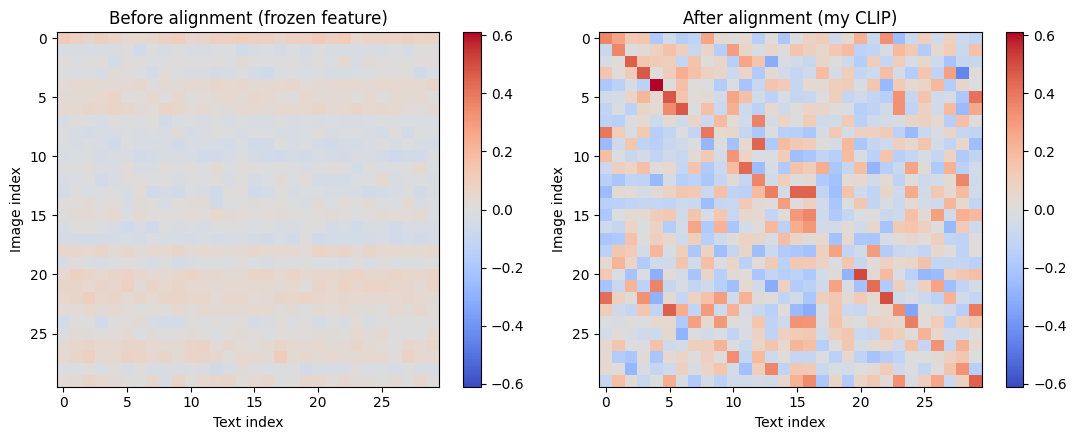

학습 후 대각선(정답) 평균 : 0.3545
학습 후 비대각선(오답) 평균: -0.0018


In [ ]:
sim_before30 = sim_raw[:30, :30].numpy()
sim_after30 = sim_trained[:30, :30].numpy()
vmax = max(abs(sim_before30).max(), abs(sim_after30).max())

plt.figure(figsize=(11, 4.5))
for k, (title, s) in enumerate([("Before alignment (frozen feature)", sim_before30),
                                ("After alignment (my CLIP)", sim_after30)]):
    plt.subplot(1, 2, k + 1)
    # 두 subplot에 같은 색 범위(-vmax~vmax)와 0 기준 diverging colormap을 써서
    # "대각선이 얼마나 도드라지는지"를 두 그림에서 공정하게 비교할 수 있게 합니다.
    plt.imshow(s, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    plt.title(title)
    plt.xlabel("Text index")
    plt.ylabel("Image index")
    plt.colorbar()
plt.tight_layout()
plt.show()

diag_after = sim_trained.diag()
off_after = sim_trained.clone().fill_diagonal_(float("nan"))
print("학습 후 대각선(정답) 평균 : %.4f" % diag_after.mean().item())
print("학습 후 비대각선(오답) 평균: %.4f" % np.nanmean(off_after.numpy()))



#### 🖼️ 10. 학습된 모델이 어떻게 맞히고 틀리는지 보기

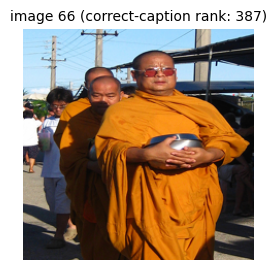

  1. [X] 0.347  A dirty tan dog rolling in the dirt and looking right at the camera .
  2. [X] 0.287  A bearded man on a train
  3. [X] 0.284  A man in a tropical enviorment holding a camera to his face .



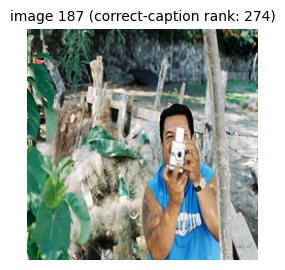

  1. [X] 0.276  A young boy sits at a picnic table and drinks out of a small cup .
  2. [X] 0.263  A group of six children sit at a wooden table .
  3. [X] 0.249  A boy tries to throw water on another person with his water bottle .



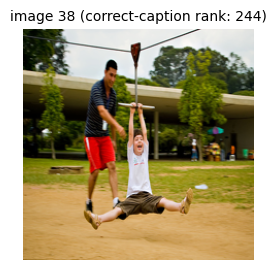

  1. [X] 0.455  A child in a white shirt and brown pants is walking through an uncut f
  2. [X] 0.401  A girl in boots is active in the grass .
  3. [X] 0.390  A little boy holds a bat waiting for the pitch on a tiled outdoor area



In [ ]:
def show_i2t(i, sim, k=3):
    """이미지 i를 query로, 정답 등수와 상위 k개 캡션을 이미지와 함께 보여줍니다."""
    rank = int((sim[i] > sim[i, i]).sum()) + 1
    scores, idxs = sim[i].topk(k)

    plt.figure(figsize=(3, 3))
    plt.imshow(img_of(test_ds, i))
    plt.axis("off")
    plt.title("image %d (correct-caption rank: %d)" % (i, rank), fontsize=10)
    plt.show()

    for r, (s, j) in enumerate(zip(scores.tolist(), idxs.tolist()), start=1):
        mark = "O" if j == i else "X"
        print("  %d. [%s] %.3f  %s" % (r, mark, s, test_caps[j][0].strip()[:70]))


# 정답 등수가 가장 안 좋은 이미지 몇 개를 골라 확인
ranks = (sim_trained > sim_trained.diag().unsqueeze(1)).sum(dim=1) + 1
worst = ranks.topk(3).indices.tolist()
for i in worst:
    show_i2t(i, sim_trained)
    print()


#### 🆚 보너스 — 사전학습 CLIP과 비교해보기

지금까지는 encoder는 얼린 채 linear projection 2개와 temperature만 학습시켜 retrieval 성능을 끌어올렸습니다.
그렇다면 encoder까지 image-text pair로 통째로 학습된 "진짜" 사전학습 CLIP은 같은 test set에서 얼마나 잘할까요?
공개 체크포인트(`openai/clip-vit-base-patch32`)를 불러와 지금까지 쓴 `test_ds`, `test_caps`에 그대로 적용해 비교합니다.


In [ ]:
from transformers import CLIPModel, CLIPProcessor

CLIP_CKPT = "openai/clip-vit-base-patch32"
clip_model_b = CLIPModel.from_pretrained(CLIP_CKPT).to(device).eval()
clip_proc = CLIPProcessor.from_pretrained(CLIP_CKPT)

with torch.no_grad():
    pretrained_images = [test_ds[i]["image"].convert("RGB") for i in range(N_TEST_IMAGES)]
    pretrained_captions = [c[0] for c in test_caps]

    img_inputs = clip_proc(
        images=pretrained_images,
        return_tensors="pt"
    ).to(device)

    txt_inputs = clip_proc(
        text=pretrained_captions,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    outputs = clip_model_b(
        pixel_values=img_inputs["pixel_values"],
        input_ids=txt_inputs["input_ids"],
        attention_mask=txt_inputs["attention_mask"]
    )

    pretrained_test_img = outputs.image_embeds.cpu()
    pretrained_test_txt = outputs.text_embeds.cpu()

sim_pretrained = pretrained_test_img @ pretrained_test_txt.T
res_pretrained = retrieval_scores(sim_pretrained)

compare_all = pd.DataFrame(
    [raw, res_half, res_infonce, res_pretrained],
    index=[
        "정렬 전 (frozen feature)",
        "절반만 학습 (image->text만)",
        "정렬 후 (my CLIP)",
        "사전학습 공개 CLIP (그대로)"
    ],
)

display(format_compare(compare_all))

print()
print("대각선(정답) 평균 cosine similarity: %.4f"
      % sim_pretrained.diag().mean().item())


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.2%,1.2%,2.0%,252.0,0.0%,1.0%,2.0%,248.0
절반만 학습 (image->text만),23.0%,53.8%,67.6%,5.0,21.4%,50.8%,66.0%,5.0
정렬 후 (my CLIP),22.2%,54.8%,66.6%,5.0,22.2%,51.6%,67.8%,5.0
사전학습 공개 CLIP (그대로),64.8%,89.2%,95.6%,1.0,61.2%,88.8%,94.4%,1.0



대각선(정답) 평균 cosine similarity: 0.3186


#### 📝 서술형 문제 2

1. 7장(절반만 학습)과 8장(대칭 학습)의 `i2t R@1`, `t2i R@1`을 모두 활용해 답변하세요.
   `i2t`는 비슷한데 `t2i`만 크게 다르다면, `loss_t`가 정확히 어떤 축을 최적화하는지와 연결해 그 이유를 설명하세요.절반만 학습했을 때 i2t R@1은 23.0%, t2i R@1은 21.4%이고 대칭 학습에서는 각각 22.2%, 22.2%다 loss_t는 열 방향인 text → image를 직접 최적화하므로 t2i 성능을 맞춰 주는 역할을 하지만 이번 결과에서는 차이가 크지는 않다
2. 정렬 전과 정렬 후의 `i2t R@1`, `i2t medr`를 인용하고 chance와 비교하세요.
   backbone은 하나도 학습하지 않았는데 이런 변화가 생겼습니다. Linear projection 두 개가 한 일을 한 문장으로 정의하세요.정렬 전 i2t R@1은 0.2%로 chance 0.2%와 같고 i2t medr도 252로 chance 250과 비슷하지만 정렬 후에는 22.2%, 5까지 개선됐다 Linear projection 두 개는 서로 다른 image와 text 공간을 정답 pair가 가까워지는 공동 공간으로 정렬한 것이다
3. 위 실패 사례의 이미지와 캡션을 보고, 이 오답이 모델이 의미를 못 맞춘 것인지 정답 캡션이 원래 애매한 것인지 판단하고 근거를 쓰세요.세 이미지 모두 정답 caption이 실제 이미지 내용과 잘 맞고 5개의 caption도 서로 비슷한 내용을 설명하고 있어 정답이 애매한 경우는 아니다


# 🔍 Part B. Modality Gap 관찰 (심화 선택)

Part A에서 만든 CLIP은 정렬 전 chance 수준이던 retrieval 성능을 학습만으로 크게 끌어올렸습니다.
그런데 "정렬에 성공했다"는 것과 "두 modality의 embedding이 공간에서 완전히 같은 자리에 있다"는 것은
서로 다른 이야기입니다. 사전학습이 훨씬 많이 된 공개 CLIP조차도 이미지 embedding들과 텍스트 embedding들이
공간 안에서 서로 떨어진 두 덩어리를 이룬다는 사실이 알려져 있습니다. 이 현상을 modality gap이라 부릅니다.

> 이 파트는 아래 논문을 활용합니다. 시간이 되시면 꼭 한번 읽어보면 좋은 논문입니다.
> - Liang, Zhang, Kwon, Yeung, Zou. [Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning](https://arxiv.org/abs/2203.02053) (NeurIPS 2022)

> **안내**
> - 여기서부터는 심화 선택입니다. Part A를 먼저 마친 뒤 하고 싶으신분들은 이어서 진행하세요.

### 📦 11. 사전학습 CLIP 불러오기 & embedding 뽑기

이번에는 CLIP을 직접 학습시키지 않고, 이미 image-text 쌍으로 학습이 끝난 공개 체크포인트를 그대로 불러옵니다.
(체크포인트 자체는 Part A 끝의 보너스 비교에서 이미 불러왔으므로, 여기서는 재사용합니다.)
Part A와 같은 Flickr8k에서 이미지 일부를 새로 가져와, 이 모델의 embedding 공간을 관찰합니다.


In [ ]:
from sklearn.decomposition import PCA

N_GAP_IMAGES = 300
# CLIP_CKPT, clip_model_b, clip_proc는 Part A 끝의 보너스 비교 셀에서 이미 불러왔습니다.

gap_ds = load_dataset("jxie/flickr8k", split=f"test[0:{N_GAP_IMAGES}]")
gap_captions = [gap_ds[i]["caption_0"].strip() for i in range(N_GAP_IMAGES)]
gap_images = [gap_ds[i]["image"].convert("RGB") for i in range(N_GAP_IMAGES)]

print("이미지:", len(gap_images), "장 | 텍스트:", len(gap_captions), "개")
print("불러온 모델:", CLIP_CKPT)


#### 🧠 11-1. 이미지·텍스트 embedding 뽑기

> 📖 **논문 근거** — Section 3. 논문은 여러 공개 CLIP 계열 모델에서 이미지·텍스트 embedding을 뽑아
> 같은 방식으로 분석합니다. 우리는 그중 하나인 공개 CLIP 체크포인트를 사용합니다.

#### ✏️ ===== TODO 10 =====
CLIP의 `get_image_features`, `get_text_features`로 embedding을 뽑고 L2 정규화하세요.
(정규화한 벡터끼리 비교해야 방향만 놓고 비교할 수 있습니다.)

In [ ]:
@torch.no_grad()
def get_embeddings(model, images, captions):
    img_inputs = clip_proc(images=images, return_tensors="pt").to(device)
    txt_inputs = clip_proc(text=captions, padding=True, truncation=True, return_tensors="pt").to(device)

    img_emb = model.get_image_features(**img_inputs)
    txt_emb = model.get_text_features(**txt_inputs)

    # ===== TODO 10 =====
    # 힌트: 각 벡터를 자기 길이로 나누면 L2 정규화. (dim=-1 기준)
    img_emb = None   # TODO: 여기에 코드를 작성하세요
    txt_emb = None   # TODO: 여기에 코드를 작성하세요
    # ==================
    return img_emb.cpu(), txt_emb.cpu()


gap_img_emb, gap_txt_emb = get_embeddings(clip_model_b, gap_images, gap_captions)
print("이미지 embedding:", tuple(gap_img_emb.shape))
print("텍스트 embedding:", tuple(gap_txt_emb.shape))
print("정답 pair(대각선) cosine similarity 평균: %.4f" % (gap_img_emb * gap_txt_emb).sum(-1).mean().item())

### 🗺️ 12. 두 modality가 실제로 겹쳐 있는지 시각화

정답 pair의 cosine similarity가 꽤 높게 나왔을 겁니다. CLIP이 정렬을 잘 했다는 뜻처럼 보입니다.
그런데 "정답 이미지와 정답 캡션이 가깝다"는 것과 "이미지 embedding들과 텍스트 embedding들이 같은 자리에 섞여 있다"는
것은 다른 이야기입니다. 후자를 직접 눈으로 확인해 보겠습니다.

#### ✏️ ===== TODO 11 =====
이미지·텍스트 embedding을 이어붙여 2차원으로 축소(PCA)한 뒤, modality별로 다른 색으로 산점도를 그리세요.

In [ ]:
gap_all_emb = torch.cat([gap_img_emb, gap_txt_emb], dim=0).numpy()
# ===== TODO 11 =====
# 힌트: PCA(n_components=2).fit_transform(all_emb)로 2차원 좌표를 얻으세요.
coords = None   # TODO: 여기에 코드를 작성하세요
# ==================

img_xy, txt_xy = coords[:N_GAP_IMAGES], coords[N_GAP_IMAGES:]

plt.figure(figsize=(6, 6))
plt.scatter(img_xy[:, 0], img_xy[:, 1], s=10, alpha=0.6, label="image embedding")
plt.scatter(txt_xy[:, 0], txt_xy[:, 1], s=10, alpha=0.6, label="text embedding")
plt.legend()
plt.title("Pretrained CLIP embeddings (PCA)")
plt.show()

### 🎲 13. Gap은 학습 때문에 생기는가, 초기화 때문에 생기는가

방금 본 두 덩어리가 "이미지와 텍스트는 원래 다른 정보라서 학습을 아무리 잘 해도 어쩔 수 없이 나뉜다"는
의미인지, 아니면 CLIP이 아직 정렬을 다 끝내지 못한 흔적인지는 이 그림만으로 알 수 없습니다.

Liang et al.(2022)은 여기서 반직관적인 실험을 합니다. **학습을 전혀 하지 않은, 무작위로 초기화된 encoder**로
같은 실험을 반복한 것입니다. 결과는 놀랍게도 학습된 CLIP과 비슷한 정도로 두 modality가 갈라졌습니다.
논문은 이를 cone effect라 부릅니다 — 무작위로 초기화된 신경망도 입력을 공간 전체가 아니라
좁은 원뿔(cone) 안으로만 내보내는 경향이 있고, 이미지 encoder와 텍스트 encoder는 서로 다른 무작위 초기화에서
출발하므로 서로 다른 cone에 놓이게 됩니다. 즉 gap의 상당 부분은 정렬 학습이 실패해서가 아니라,
애초에 구조가 다른 두 신경망을 무작위로 초기화하는 순간부터 이미 정해져 있다는 것입니다.

우리도 같은 실험을 해 봅니다. CLIP과 구조는 같지만 사전학습되지 않은, 무작위 가중치의 CLIP을 만들어 비교합니다.

#### ✏️ ===== TODO 12 =====
`CLIPModel`을 config만 가져와 랜덤 초기화로 새로 만드세요. (`CLIPModel(config)`은 가중치를 내려받지 않고 무작위로 초기화합니다.)

In [ ]:
torch.manual_seed(MY_SEED)
random_config = CLIPConfig.from_pretrained(CLIP_CKPT)
# ===== TODO 12 =====
# 힌트: from_pretrained가 아니라 config만 넘겨 생성자를 호출하면 가중치가 무작위로 초기화됩니다.
random_clip = None   # TODO: 여기에 코드를 작성하세요
# ==================

rand_img_emb, rand_txt_emb = get_embeddings(random_clip, gap_images, gap_captions)

rand_all = torch.cat([rand_img_emb, rand_txt_emb], dim=0).numpy()
rand_coords = PCA(n_components=2).fit_transform(rand_all)
rand_img_xy, rand_txt_xy = rand_coords[:N_GAP_IMAGES], rand_coords[N_GAP_IMAGES:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, (title, ixy, txy) in zip(axes, [
    ("Pretrained CLIP", img_xy, txt_xy),
    ("Randomly initialized CLIP (untrained)", rand_img_xy, rand_txt_xy),
]):
    ax.scatter(ixy[:, 0], ixy[:, 1], s=10, alpha=0.6, label="image")
    ax.scatter(txy[:, 0], txy[:, 1], s=10, alpha=0.6, label="text")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

### 📏 14. Gap을 숫자로 재보기

> 📖 **논문 근거** — Section 3. 두 modality 각각의 embedding 중심(평균)을 구하고,
> 그 사이의 유클리드 거리를 gap의 크기(Δ)로 정의합니다.

#### ✏️ ===== TODO 13 =====
사전학습 CLIP과 무작위 초기화 CLIP 각각에서, 이미지 중심과 텍스트 중심 사이의 유클리드 거리를 구하세요.

In [ ]:
def modality_gap(img_e, txt_e):
    # ===== TODO 13 =====
    # 힌트: 각 modality의 중심(평균 벡터)을 구한 뒤, 두 중심 사이의 유클리드 거리(L2 norm)를 구하세요.
    img_center = None   # TODO: 여기에 코드를 작성하세요
    txt_center = None   # TODO: 여기에 코드를 작성하세요
    return None         # TODO: 여기에 코드를 작성하세요
    # ==================


gap_pretrained = modality_gap(gap_img_emb, gap_txt_emb)
gap_random = modality_gap(rand_img_emb, rand_txt_emb)

print("사전학습 CLIP의 gap      : %.4f" % gap_pretrained)
print("무작위 초기화 CLIP의 gap : %.4f" % gap_random)
print()
print("두 modality가 완전히 같은 자리에 있다면 gap은 0에 가까워야 합니다.")

#### 📝 서술형 문제 3 (심화 선택)

1. 12장의 산점도와 14장의 gap 숫자를 함께 인용해서, 사전학습 CLIP이 "정렬에 실패했다"고 말할 수 있는지 판단하세요.
   (11-1에서 본 정답 pair의 cosine similarity가 높았다는 사실과 지금 gap이 크다는 사실이 왜 모순이 아닌지 함께 설명하세요.)
2. 무작위 초기화 CLIP에서도 gap이 상당히 크게 나왔다면, 그 이유를 13장의 cone effect로 설명하세요.
   만약 이미지 encoder와 텍스트 encoder를 완전히 같은 방식으로 초기화한다면 gap이 어떻게 될지 추론해 보세요.


#### 🤔 회고

Part A에서 겪은 어려움과 해결 과정을 3-5문장으로 적습니다. 끝까지 헷갈린 개념 1-3개도 함께: image와 text feature의 차원이 같아도 바로 비교할 수 없다는 점이 처음에는 헷갈렸다
l2norm과 projection을 적용하고 정렬 전후 retrieval 결과를 비교하면서 두 공간을 맞추는 과정이 필요하다는 것을 이해했다

Part B(심화 선택)를 진행했다면, 새롭게 알게 된 점을 이어서 적어도 좋습니다: (여기에 답)

#### ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 코드 todo채울때 사용하였고 중간에 보너스 부분이 실행이 안되서 지피티 이용해서 새로운 코드 짜서 확인했음

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: ai가 틀린값을 주지는 않았던것같다

- **실제 대화 내역** 붙여넣기:

```
이 코드는 지금 transformers 버전에서 get_image_features() 반환 방식이 달라져서 오류가 난 거라 아래처럼 전체 블록을 바꾸는 게 제일 깔끔하다
from transformers import CLIPModel, CLIPProcessor

CLIP_CKPT = "openai/clip-vit-base-patch32"
clip_model_b = CLIPModel.from_pretrained(CLIP_CKPT).to(device).eval()
clip_proc = CLIPProcessor.from_pretrained(CLIP_CKPT)

with torch.no_grad():
    pretrained_images = [test_ds[i]["image"].convert("RGB") for i in range(N_TEST_IMAGES)]
    pretrained_captions = [c[0] for c in test_caps]

    img_inputs = clip_proc(
        images=pretrained_images,
        return_tensors="pt"
    ).to(device)

    txt_inputs = clip_proc(
        text=pretrained_captions,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    outputs = clip_model_b(
        pixel_values=img_inputs["pixel_values"],
        input_ids=txt_inputs["input_ids"],
        attention_mask=txt_inputs["attention_mask"]
    )

    pretrained_test_img = outputs.image_embeds.cpu()
    pretrained_test_txt = outputs.text_embeds.cpu()

sim_pretrained = pretrained_test_img @ pretrained_test_txt.T
res_pretrained = retrieval_scores(sim_pretrained)

compare_all = pd.DataFrame(
    [raw, res_half, res_infonce, res_pretrained],
    index=[
        "정렬 전 (frozen feature)",
        "절반만 학습 (image->text만)",
        "정렬 후 (my CLIP)",
        "사전학습 공개 CLIP (그대로)"
    ],
)

display(format_compare(compare_all))

print()
print("대각선(정답) 평균 cosine similarity: %.4f"
      % sim_pretrained.diag().mean().item())
여기서는 outputs.image_embeds와 outputs.text_embeds가 이미 CLIP의 projection과 정규화를 거친 벡터라서 l2norm을 다시 적용하지 않아도 된다
즉 네 기존 코드의 get_image_features() 부분 때문에 난 오류고 위 코드로 셀 전체 교체해서 실행하면 된다

def loss_infonce(cos, model):
    labels = torch.arange(cos.size(0), device=cos.device)
    logits = model.scale() * cos

    # ===== TODO 9 =====
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return (loss_i + loss_t) / 2
    # ==================
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요?
실제 이미지와 caption을 보고 모델의 오답이 왜 발생했는지 직접 판단한 것


#### 📚 참고 자료

**CLIP 직접 구현 (Part A)**
- CLIP: [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020) (Radford et al., 2021)
- ViT: [An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929) (Dosovitskiy et al., 2021)
- DistilBERT: [DistilBERT, a distilled version of BERT](https://arxiv.org/abs/1910.01108) (Sanh et al., 2019)
- Flickr8k: [Framing Image Description as a Ranking Task](https://www.jair.org/index.php/jair/article/view/10833) (Hodosh et al., 2013)

**Modality Gap 관찰 (Part B, 심화 선택)**
- Liang, Zhang, Kwon, Yeung, Zou. [Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning](https://arxiv.org/abs/2203.02053) (NeurIPS 2022)